In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
image1 = cv2.imread('eiffel1.jpg')
image2 = cv2.imread('eiffel2.jpg')
print(image1.shape)
print(image2.shape)
image1 = cv2.resize(image1, (400, 400))
image2 = cv2.resize(image2, (400, 400))


(1002, 626, 3)
(408, 612, 3)


In [6]:
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

In [7]:
sift = cv2.SIFT_create()
keypoint1 = sift.detect(gray1, None)
keypoint2 = sift.detect(gray2, None)
print(len(keypoint1))
print(len(keypoint2))

620
757


In [8]:
imagekp1 = cv2.drawKeypoints(gray1, keypoint1, gray1)
imagekp2 = cv2.drawKeypoints(gray2, keypoint2, gray2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

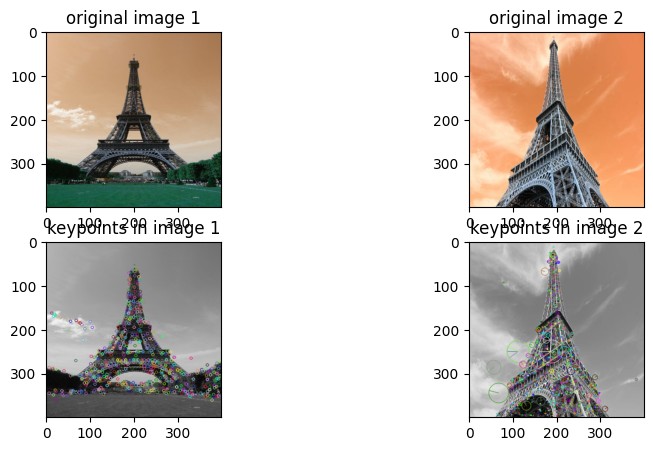

In [9]:
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(image1)
plt.title('original image 1')
plt.subplot(2, 2, 2)
plt.imshow(image2)
plt.title('original image 2')
plt.subplot(2, 2, 3)
plt.imshow(imagekp1)
plt.title('keypoints in image 1')
plt.subplot(2, 2, 4)
plt.imshow(imagekp2)
plt.title('keypoints in image 2')
plt.show()

In [10]:
kp1, des1 = sift.compute(gray1, keypoint1)
kp2, des2 = sift.detectAndCompute(gray2, None)

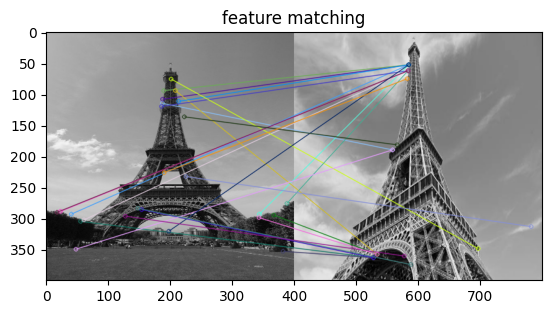

In [11]:
#feature matching
bf = cv2.BFMatcher(cv2.NORM_L1)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)
img3 = cv2.drawMatches(gray1, kp1, gray2, kp2, matches[:25], gray2, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3)
plt.title('feature matching')
plt.show()

# **SURF**

In [12]:
image_1 = cv2.imread('eiffel1.jpg')
image_2 = cv2.imread('eiffel2.jpg')
gray_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2GRAY)
gray_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2GRAY)

In [13]:
surf = cv2.xfeatures2d.SURF_create()
keypoint_1 = surf.detect(gray_1, None)
keypoint_2 = surf.detect(gray_2, None)
print(len(keypoint_1))
print(len(keypoint_2))

AttributeError: module 'cv2' has no attribute 'xfeatures2d'

In [ ]:
surf.upright = True
surf.extended = True
image_kp1 = cv2.drawKeypoints(gray_1, keypoint_1, gray_1)
image_kp2 = cv2.drawKeypoints(gray_2, keypoint_2, gray_2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


In [ ]:
kp_1, des_1 = surf.compute(gray_1, keypoint_1)
kp_2, des_2 = surf.detectAndCompute(gray_2, None)

In [ ]:
#feature matching
bf = cv2.BFMatcher(cv2.NORM_L1)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)
img_3 = cv2.drawMatches(gray1, kp1, gray2, kp2, matches[:50], gray2, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_3)
plt.title('feature matching')
plt.show()